# Домашно 1




### В това домашно задачата ви е да класифицирате всяка картинка от тестовото множество във 53-те различни класа. Накрая покажете какво е accuracy-то на вашия модел върху това тестово множество. (Accuracy = Correct/Total).

In [ ]:
#!pip install torch torchvision tqdm torchsummary

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from timeit import default_timer as timer
from PIL import Image
import os

from google.colab import files

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")


PyTorch version : 2.10.0+cu128
Torchvision     : 0.25.0+cu128
GPU available   : True


## Зареждане на Dataset-а от Kaggle


In [ ]:
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d gpiosenka/cards-image-datasetclassification
!unzip -q cards-image-datasetclassification.zip -d cards-image-datasetclassification


Dataset URL: https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification
License(s): CC0-1.0
cards-image-datasetclassification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace cards-image-datasetclassification/14card types-14-(200 X 200)-94.61.h5? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
df = pd.read_csv("/content/cards-image-datasetclassification/cards.csv")
print(df.shape)
df.head()


(8155, 5)


,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


## Data Augmentation


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


## Personalize Dataset class

In [ ]:
BASE_DIR = "/content/cards-image-datasetclassification"

class CardsDataset(Dataset):
    """Зарежда изображения на карти по пътека от CSV."""

    def __init__(self, dataframe, base_dir, transform=None):
        """
        Args:
            dataframe : pandas DataFrame с колони filepaths, labels, class index
            base_dir  : корен на папката с изображенията
            transform : torchvision трансформации
        """
        self.df        = dataframe.reset_index(drop=True)
        self.base_dir  = base_dir
        self.transform = transform

        self.classes   = sorted(self.df["labels"].unique().tolist())
        self.class2idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)


    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        path     = os.path.join(self.base_dir, row["filepaths"])

        image = Image.open(path).convert("RGB")
        label = self.class2idx[row["labels"]]
        if self.transform:
            image = self.transform(image)
        return image, label



valid_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp')
df_filtered = df[df['filepaths'].apply(lambda x: x.lower().endswith(valid_extensions) and os.path.isfile(os.path.join(BASE_DIR, x)))]

train_df = df_filtered[df_filtered["data set"] == "train"]
valid_df = df_filtered[df_filtered["data set"] == "valid"]
test_df  = df_filtered[df_filtered["data set"] == "test"]

train_dataset = CardsDataset(train_df, BASE_DIR, transform=train_transforms)
valid_dataset = CardsDataset(valid_df, BASE_DIR, transform=val_test_transforms)
test_dataset  = CardsDataset(test_df,  BASE_DIR, transform=val_test_transforms)

print(f"Train samples : {len(train_dataset)}")
print(f"Valid samples : {len(valid_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Брой класове  : {len(train_dataset.classes)}")


Train samples : 7624
Valid samples : 265
Test  samples : 265
Брой класове  : 53


## DataLoader

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=True
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True
)
test_loader  = DataLoader(
    test_dataset,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True
)

imgs, labels = next(iter(train_loader))
print(f"Batch images shape : {imgs.shape}")    # (32, 3, 224, 224)
print(f"Batch labels shape : {labels.shape}")  # (32,)


Batch images shape : torch.Size([32, 3, 224, 224])
Batch labels shape : torch.Size([32])


### Визуализация на данните


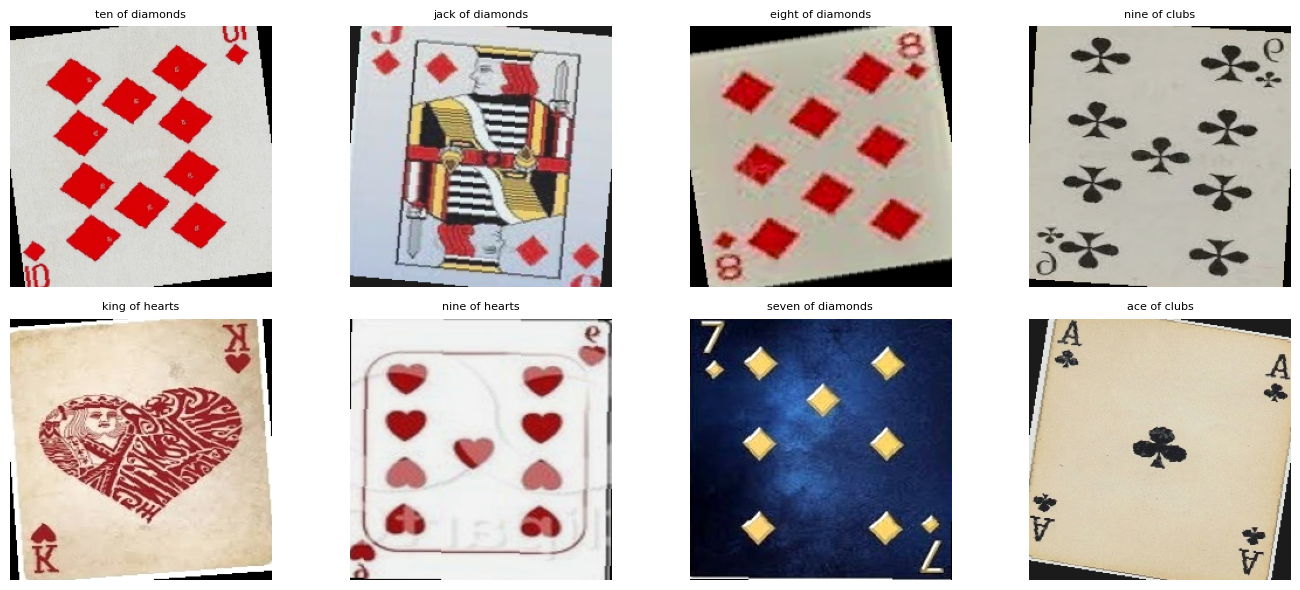

In [ ]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Обръща нормализацията за визуализация."""
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)


def show_batch(loader, class_names, n=8):
    imgs, labels = next(iter(loader))
    fig, axes    = plt.subplots(2, n // 2, figsize=(14, 6))
    for i, ax in enumerate(axes.flatten()):
        img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(class_names[labels[i].item()], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, train_dataset.classes)


## Архитектури на моделите

Ще тестваме **три различни подхода** и ще сравним резултатите им:

| Модел | Описание |
|---|---|
| **Baseline CNN** | Прост CNN, изграден от нулата |
| **ResNet-18 (Frozen)** | Transfer Learning |
| **EfficientNet-B0 (Fine-tuned)** | Fine-tuning |


In [ ]:
class BaselineCNN(nn.Module):
    """
    Прост CNN.
    Вход:  (batch, 3, 224, 224)
    Изход: (batch, 53)  – 53 логита, по един на клас
    """

    def __init__(self, num_classes: int = 53):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
def build_resnet18_frozen(num_classes: int = 53):
    model = torchvision.models.resnet18(
        weights=torchvision.models.ResNet18_Weights.DEFAULT
    )

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features   # = 512
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )

    return model


In [ ]:
def build_efficientnet_ft(num_classes: int = 53):
    model = torchvision.models.efficientnet_b0(
        weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
    )

    in_features = model.classifier[1].in_features  # = 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )

    return model


## Training cycle

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Използваме: {device}")

def accuracy_fn(y_true, y_pred):
    correct = (y_true == y_pred).sum().item()
    return 100.0 * correct / len(y_true)


def train_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, total_acc = 0.0, 0.0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        logits = model(X)
        loss   = loss_fn(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds       = logits.argmax(dim=1)
        total_loss += loss.item()
        total_acc  += accuracy_fn(y, preds)

    n = len(loader)
    return total_loss / n, total_acc / n


@torch.inference_mode()
def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_acc = 0.0, 0.0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        logits      = model(X)
        loss        = loss_fn(logits, y)
        preds       = logits.argmax(dim=1)

        total_loss += loss.item()
        total_acc  += accuracy_fn(y, preds)

    n = len(loader)
    return total_loss / n, total_acc / n


def train_model(model, train_loader, valid_loader,
                loss_fn, optimizer, scheduler,
                epochs, device, model_name="model"):
    model.to(device)
    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}

    for epoch in tqdm(range(epochs), desc=model_name):
        t0 = timer()

        tr_loss, tr_acc = train_epoch(model, train_loader, loss_fn, optimizer, device)
        va_loss, va_acc = eval_epoch(model,  valid_loader, loss_fn, device)

        if scheduler:
            scheduler.step()

        t1 = timer()
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | "
            f"Val Loss: {va_loss:.4f} Acc: {va_acc:.2f}% | "
            f"Time: {t1-t0:.1f}s"
        )

    return history


Използваме: cuda


## Експеримент 1 – Baseline CNN


In [ ]:
EPOCHS_BASELINE = 20
LR_BASELINE     = 1e-3
NUM_CLASSES     = 53

model_baseline = BaselineCNN(num_classes=NUM_CLASSES).to(device)

loss_fn       = nn.CrossEntropyLoss()
optimizer_bl  = torch.optim.AdamW(
    model_baseline.parameters(), lr=LR_BASELINE, weight_decay=1e-4
)
scheduler_bl  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_bl, T_max=EPOCHS_BASELINE
)

history_baseline = train_model(
    model_baseline, train_loader, valid_loader,
    loss_fn, optimizer_bl, scheduler_bl,
    epochs=EPOCHS_BASELINE, device=device,
    model_name="Baseline CNN"
)


Baseline CNN:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 3.3607 Acc: 11.22% | Val Loss: 2.7199 Acc: 18.25% | Time: 30.9s
Epoch 02/20 | Train Loss: 2.7124 Acc: 21.27% | Val Loss: 2.2200 Acc: 31.87% | Time: 29.8s
Epoch 03/20 | Train Loss: 2.4829 Acc: 26.06% | Val Loss: 2.1260 Acc: 29.90% | Time: 29.7s
Epoch 04/20 | Train Loss: 2.3540 Acc: 29.42% | Val Loss: 1.8550 Acc: 39.51% | Time: 30.2s
Epoch 05/20 | Train Loss: 2.2587 Acc: 31.29% | Val Loss: 1.8425 Acc: 41.32% | Time: 30.2s
Epoch 06/20 | Train Loss: 2.1830 Acc: 33.02% | Val Loss: 1.6456 Acc: 45.18% | Time: 30.1s
Epoch 07/20 | Train Loss: 2.0898 Acc: 36.81% | Val Loss: 1.5424 Acc: 50.81% | Time: 29.9s
Epoch 08/20 | Train Loss: 1.9796 Acc: 40.47% | Val Loss: 1.3523 Acc: 60.15% | Time: 31.1s
Epoch 09/20 | Train Loss: 1.8438 Acc: 46.14% | Val Loss: 1.3997 Acc: 59.30% | Time: 29.6s
Epoch 10/20 | Train Loss: 1.7415 Acc: 51.10% | Val Loss: 1.1706 Acc: 67.28% | Time: 29.6s
Epoch 11/20 | Train Loss: 1.6433 Acc: 53.53% | Val Loss: 1.0829 Acc: 71.45% | Time: 30.6s
Epoch 12/2

## Експеримент 2 – ResNet-18 (Transfer Learning, Frozen)



In [ ]:
EPOCHS_FROZEN = 15
LR_FROZEN     = 5e-4

model_frozen    = build_resnet18_frozen(num_classes=NUM_CLASSES).to(device)

optimizer_fr  = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_frozen.parameters()),
    lr=LR_FROZEN, weight_decay=1e-4
)
scheduler_fr  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fr, T_max=EPOCHS_FROZEN
)

history_frozen = train_model(
    model_frozen, train_loader, valid_loader,
    loss_fn, optimizer_fr, scheduler_fr,
    epochs=EPOCHS_FROZEN, device=device,
    model_name="ResNet-18 Frozen"
)


ResNet-18 Frozen:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 3.3529 Acc: 12.59% | Val Loss: 2.5247 Acc: 25.19% | Time: 30.9s
Epoch 02/15 | Train Loss: 2.6265 Acc: 24.31% | Val Loss: 2.0811 Acc: 34.76% | Time: 30.1s
Epoch 03/15 | Train Loss: 2.3578 Acc: 30.83% | Val Loss: 1.8638 Acc: 41.90% | Time: 31.6s
Epoch 04/15 | Train Loss: 2.2159 Acc: 34.17% | Val Loss: 1.7952 Acc: 42.25% | Time: 29.9s
Epoch 05/15 | Train Loss: 2.1048 Acc: 38.23% | Val Loss: 1.6753 Acc: 47.15% | Time: 30.7s
Epoch 06/15 | Train Loss: 2.0325 Acc: 39.72% | Val Loss: 1.6573 Acc: 48.53% | Time: 30.9s
Epoch 07/15 | Train Loss: 1.9502 Acc: 42.90% | Val Loss: 1.5755 Acc: 52.51% | Time: 29.8s
Epoch 08/15 | Train Loss: 1.8930 Acc: 45.08% | Val Loss: 1.5323 Acc: 51.66% | Time: 31.1s
Epoch 09/15 | Train Loss: 1.8678 Acc: 46.16% | Val Loss: 1.5609 Acc: 50.42% | Time: 30.2s
Epoch 10/15 | Train Loss: 1.8236 Acc: 47.86% | Val Loss: 1.5548 Acc: 53.74% | Time: 31.0s
Epoch 11/15 | Train Loss: 1.7956 Acc: 47.23% | Val Loss: 1.5008 Acc: 52.85% | Time: 30.5s
Epoch 12/1

## Експеримент 3 – EfficientNet-B0 (Fine-tuning)



In [ ]:
EPOCHS_FT = 15
LR_FT     = 1e-4
model_ft     = build_efficientnet_ft(num_classes=NUM_CLASSES).to(device)

optimizer_ft = torch.optim.AdamW(
    model_ft.parameters(), lr=LR_FT, weight_decay=1e-4
)
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=EPOCHS_FT
)

history_ft = train_model(
    model_ft, train_loader, valid_loader,
    loss_fn, optimizer_ft, scheduler_ft,
    epochs=EPOCHS_FT, device=device,
    model_name="EfficientNet-B0 Fine-Tuning"
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 188MB/s]


EfficientNet-B0 Fine-Tuning:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 3.1571 Acc: 20.45% | Val Loss: 1.8743 Acc: 46.95% | Time: 42.7s
Epoch 02/15 | Train Loss: 1.8141 Acc: 52.58% | Val Loss: 0.9662 Acc: 74.58% | Time: 41.6s
Epoch 03/15 | Train Loss: 1.2005 Acc: 68.23% | Val Loss: 0.5660 Acc: 83.99% | Time: 40.8s
Epoch 04/15 | Train Loss: 0.8346 Acc: 77.52% | Val Loss: 0.3823 Acc: 88.50% | Time: 41.0s
Epoch 05/15 | Train Loss: 0.6288 Acc: 82.71% | Val Loss: 0.2568 Acc: 94.25% | Time: 40.8s
Epoch 06/15 | Train Loss: 0.4908 Acc: 86.57% | Val Loss: 0.1717 Acc: 95.29% | Time: 40.8s
Epoch 07/15 | Train Loss: 0.3983 Acc: 89.54% | Val Loss: 0.1711 Acc: 93.56% | Time: 41.8s
Epoch 08/15 | Train Loss: 0.3301 Acc: 90.90% | Val Loss: 0.1713 Acc: 93.90% | Time: 41.6s
Epoch 09/15 | Train Loss: 0.2877 Acc: 92.19% | Val Loss: 0.1151 Acc: 96.88% | Time: 41.4s
Epoch 10/15 | Train Loss: 0.2439 Acc: 93.55% | Val Loss: 0.1252 Acc: 95.29% | Time: 40.9s
Epoch 11/15 | Train Loss: 0.2296 Acc: 93.84% | Val Loss: 0.1078 Acc: 97.03% | Time: 41.0s
Epoch 12/1

## Result evaluation


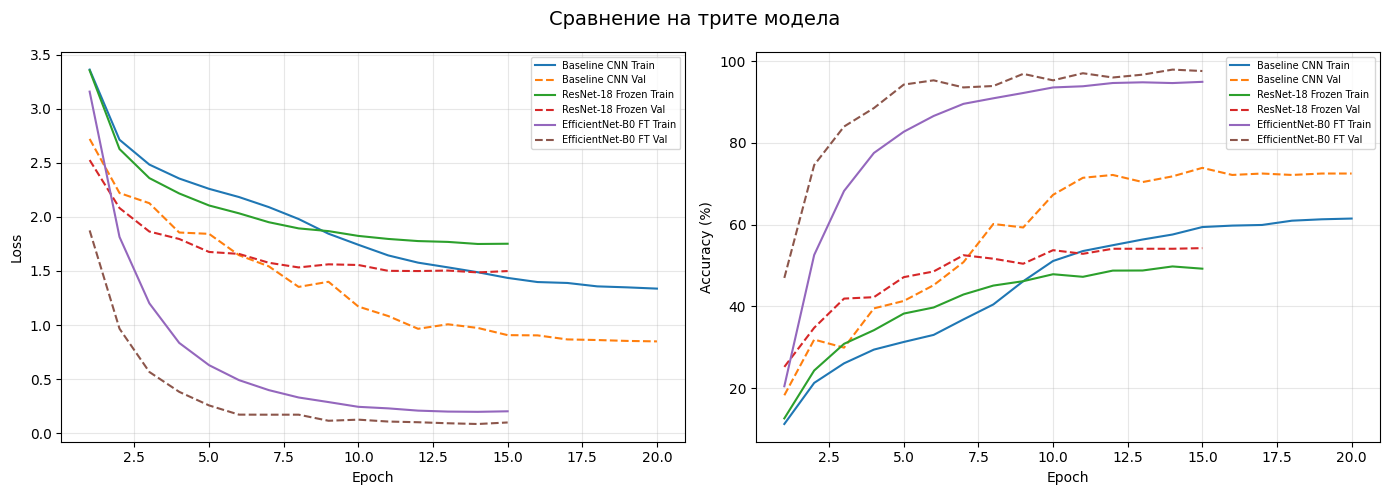

In [ ]:
def plot_training_curves(histories: dict, title: str = ""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, h in histories.items():
        epochs = range(1, len(h["train_loss"]) + 1)
        axes[0].plot(epochs, h["train_loss"], label=f"{name} Train")
        axes[0].plot(epochs, h["val_loss"],   label=f"{name} Val", linestyle="--")
        axes[1].plot(epochs, h["train_acc"],  label=f"{name} Train")
        axes[1].plot(epochs, h["val_acc"],    label=f"{name} Val",  linestyle="--")

    for ax, ylabel in zip(axes, ["Loss", "Accuracy (%)"]):
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


histories_all = {
    "Baseline CNN":      history_baseline,
    "ResNet-18 Frozen":  history_frozen,
    "EfficientNet-B0 FT": history_ft,
}

plot_training_curves(histories_all, title="Сравнение на трите модела")


In [ ]:
@torch.inference_mode()
def evaluate_test_set(model, test_loader, loss_fn, device, model_name=""):
    """Оценява модела на тестовото множество и отчита метриките."""
    test_loss, test_acc = eval_epoch(model, test_loader, loss_fn, device)
    print(f"{'─'*50}")
    print(f"  {model_name}")
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"  Test Accuracy : {test_acc:.2f}%")
    print(f"{'─'*50}")
    return test_acc


results = {}
results["Baseline CNN"]       = evaluate_test_set(model_baseline, test_loader, loss_fn, device, "Baseline CNN")
results["ResNet-18 Frozen"]   = evaluate_test_set(model_frozen,   test_loader, loss_fn, device, "ResNet-18 Frozen")
results["EfficientNet-B0 FT"] = evaluate_test_set(model_ft,       test_loader, loss_fn, device, "EfficientNet-B0 FT")

print()
best_model = max(results, key=results.get)
print(f"Най-добър модел: {best_model} с Accuracy = {results[best_model]:.2f}%")


──────────────────────────────────────────────────
  Baseline CNN
  Test Loss     : 1.1452
  Test Accuracy : 67.94%
──────────────────────────────────────────────────
──────────────────────────────────────────────────
  ResNet-18 Frozen
  Test Loss     : 1.7632
  Test Accuracy : 45.18%
──────────────────────────────────────────────────
──────────────────────────────────────────────────
  EfficientNet-B0 FT
  Test Loss     : 0.1600
  Test Accuracy : 94.79%
──────────────────────────────────────────────────

Най-добър модел: EfficientNet-B0 FT с Accuracy = 94.79%


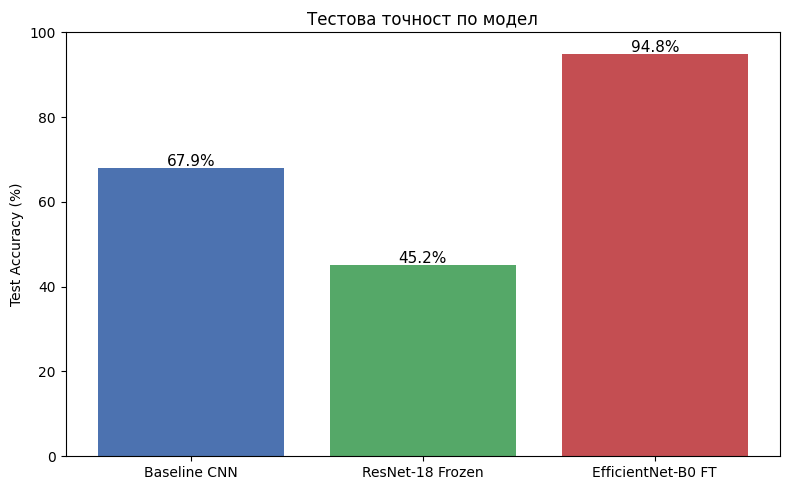

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0", "#55A868", "#C44E52"]
ax.bar(list(results.keys()), list(results.values()), color=colors)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Тестова точност по модел")
ax.set_ylim(0, 100)
for i, (name, acc) in enumerate(results.items()):
    ax.text(i, acc + 0.5, f"{acc:.1f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()
